In [36]:
%run "////home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/simulation/simulation_prereqs/impport_packages.ipynb"    #import all necessary packages - numpy, pandas etc
%run "////home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/simulation/simulation_prereqs/simulation_class.ipynb"    #import all necessary packages - numpy, pandas etc
%run "////home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/simulation/simulation_prereqs/create_world.ipynb"

### Reformulation

- Define the **maternal deviation**:


##### $\delta_t$= Phenotype of the mother - Genetic contribution of mother
##### $\delta_t$ = $P_{t-1} - G_{t-1}$

so that the phenotype is the sum of the genetic component of the current generation and maternal deviation from its phenotype:

$$
P = G_t + \omega * \delta_t + \varepsilon_{d}
$$

- We also separate mutation-related noise $\varepsilon_{m}$ from parental phenotype inheritance noise $\varepsilon_{epi}$.  
- We define a evolvable 'weight' term $\omega$: determines how much importance to give each term of the equation
- We also add developmental noise: purely environmental noise in teh form of  $\varepsilon_{d}$


The full new formulation becomes:

$$
Z' = (G_t + \varepsilon_{m}) + (\omega + \varepsilon_{epi})*(\delta_t) +  \varepsilon_{d}
$$

---

In [4]:
def run_simulation(env_param_space, popsize, maxgen, dims, N, mutsize, mutrate, epsilon, nof_dimensions, only_genetics):
    
    rho_m_alpha_beta = env_param_space[0:4]
    env_states = env_param_space[4:]

    meanw = np.zeros(maxgen)
    meanmemory_g = np.zeros(maxgen)
    meanmemory_p= np.zeros(maxgen)
    meanneutral_g = np.zeros(maxgen)
    meanneutral_p = np.zeros(maxgen)
    mean_gen = np.zeros(maxgen)
    stdmemory_p = np.zeros(maxgen)
    stdneutral_p = np.zeros(maxgen)
    
    for t in range(0, (maxgen-1)):
        #if t%10 == 0:
        #    print(t)
        for d in range(0, nof_dimensions):
            N[:,dims['dev'][d]] = N[:,dims['pheno'][d]] - env_states[t]
            
        dev_combined = np.sqrt(np.sum(N[:,dims['dev']]**2, axis =1))     
        W = np.exp((-dev_combined**2)/ (2))
        
        
        meanw[t] = np.mean(W)    
        
        meanmemory_g[t] = np.mean(N[:, dims['memory']])  # the actual memory
        meanmemory_p[t] = np.mean(1/(1 + np.exp(-N[:,dims['memory']]))) #with the logistc correction
        
        meanneutral_g[t] = np.mean(N[:,dims['neutral']])
        meanneutral_p[t] = np.mean(1/(1 + np.exp(-N[:,dims['neutral']])))
        mean_gen[t] = np.mean(N[:,dims['geno']])
        
        stdmemory_p[t] = np.std(1/(1 + np.exp(-N[:,dims['memory']])))
        stdneutral_p[t] = np.std(1/(1 + np.exp(-N[:,dims['neutral']])))
        
        #current gen offspring (the cube gets stored here per gen)
        
        offspring = np.zeros((popsize, dims['total_layers'])) # empty 3D matrix with dimensions of the cube
        
        #sample offspring for each scenario weighted by fitness
        
        
        parents_idx = np.random.choice(popsize, size=popsize, p = (W/np.sum(W)) )#pick #popsize sized random numbers
        offspring[:,:] = N[parents_idx, :] #similar to how it works in matlab
        
        mutate_memories = np.random.uniform(low=0, high=1, size= popsize) < mutrate[0]
        #mutate_neutral = np.random.uniform(low=0, high=1, size=popsize) < mutrate[0]
        mutate_geno = np.random.uniform(low=0, high=1, size=(popsize, nof_dimensions)) < mutrate[1]
        
        # adding a mutation of size mutsize[1], rate mutate_memories, to the epi-memory
        # the epignetic memory evolves; 
        
        offspring[:,dims['memory']] = (
                                offspring[:,dims['memory']] 
                                + mutate_memories * np.random.normal(0, mutsize[0], popsize)
        )
        
        # adding a mutation of size mutsize[1] (epi-mutation size), rate mutate_memories, to the neutral phenotype
        # the neutral trait recieves random mutation but is not implemented in the calculation for fitness; so is evolving neutrally
        offspring[:,dims['neutral']] = (
                                offspring[:,dims['neutral']]  
                                + mutate_memories * np.random.normal(0, mutsize[0], popsize)
        ) 
        
        # adding a mutation of size mutsize[2] (genetic mutation size), rate mutate_memories, to the genotype

        offspring[:,dims['geno']] = (
                            offspring[:,dims['geno']] 
                            + mutate_geno * np.random.normal(0, mutsize[1], size=(popsize, nof_dimensions) )
        )
        
        if only_genetics :
            if t % 10000 == 0:
                print(f"Gen {t}: Running ONLY genetics mode")
            
            for i in range(0, nof_dimensions):
                offspring[:, dims['pheno'][i]] = (
                offspring[:, dims['geno'][i]]
                + np.random.normal(0, epsilon, size=popsize) )
        else:
            if t % 10000 == 0:
                print(f"Gen {t}: Running EPIGENETIC mode")
            
            for i in range(0, nof_dimensions):
                    offspring[:, dims['pheno'][i]] = (
                        offspring[:, dims['geno'][i]] #genotype
                        + np.random.normal(0, epsilon, size=popsize) # adding random noise (developemental noise, nromally distributed with epsilon variance)
                        + ((1 / (1 + np.exp(-offspring[:, dims['memory']]))) #phenotype version of the memory (y axis) 
                        * (N[parents_idx, dims['pheno'][i]] - N[parents_idx, dims['geno'][i]]))# adding the deviation -> read as weight (phenotypic component * deviation)
                    )
        N = offspring
        
        
    return {                ## Make sure this is indented!!
        'maxgen_popsize': [maxgen,popsize],
        'rho_m_alpha_beta' :rho_m_alpha_beta,
        'meanw': meanw,
        'meanmemory_g': meanmemory_g,
        'meanmemory_p': meanmemory_p,
        'meanneutral_g': meanneutral_g,
        'meanneutral_p': meanneutral_p,
        'mean_geno': mean_gen,
        'std_memory_p': stdmemory_p,
        'std_neutral_p': stdneutral_p
        }
        

In [28]:

clean_data_env = np.concatenate([
    np.zeros(4),       # first 4 zeros
    np.zeros(10000),    # 5000 zeros
    np.zeros(100000-10000)      # 5000 ones
])
clean_data_env

array([0., 0., 0., ..., 0., 0., 0.], shape=(100004,))

In [37]:
maxgen = 100000
full_env_values = create_world(1, 1, maxgen)   # create world (input: generations, no. rhos and no. ms) 
print(full_env_values.shape)

clean_data_env = full_env_values[~np.isnan(full_env_values).any(axis=1)][0]
clean_data_env

(1, 100004)


array([0.1 , 0.5 , 0.45, ..., 0.  , 1.  , 1.  ], shape=(100004,))

In [38]:

nof_scenarios = 1
print('nof_scenarios:', nof_scenarios) 

rho_m_alpha_beta = clean_data_env[0:4]
env_states = clean_data_env[4:]


nof_scenarios: 1


In [39]:
popsize = 5000

# Mutation rates: [epi-memory mutation rate, geno mutation rate]
mutrate = [0.001, 0.001]

# Mutation sizes: [epi-memory mutation size, geno mutation size]
mutsize = [1, 1]

epsilon = 0.05 # phenotypic noise
                                 
initial_memory = 0

results_array = {}  ### DONT FORGET TO RUN BEFORE NEW PARAM CONDITIONS

mutrate[0]*mutsize[0]

maxgen = 100000

 mutrate = [0.0001, 0.0001] seems to produce mutation sizes that are good enouhgh for for attaining high values and not fluctuating a lot because of too much highness

In [40]:
onlygen = False

# Number of dimensions (can be 1 or more)
nof_dimensions = 1

# get the cube dimensions
dims = get_cube_dims(nof_dimensions)

#create the cube
N = create_cube(popsize, dims=dims, nof_dimensions=nof_dimensions, epsilon=epsilon, initial_memory=initial_memory)

print(N.shape)


(5000, 5)


In [41]:
const = run_simulation(clean_data_env, popsize, maxgen, dims, N, mutsize, mutrate, epsilon, nof_dimensions, False)
    


Gen 0: Running EPIGENETIC mode
Gen 10000: Running EPIGENETIC mode
Gen 20000: Running EPIGENETIC mode
Gen 30000: Running EPIGENETIC mode
Gen 40000: Running EPIGENETIC mode
Gen 50000: Running EPIGENETIC mode
Gen 60000: Running EPIGENETIC mode
Gen 70000: Running EPIGENETIC mode
Gen 80000: Running EPIGENETIC mode
Gen 90000: Running EPIGENETIC mode


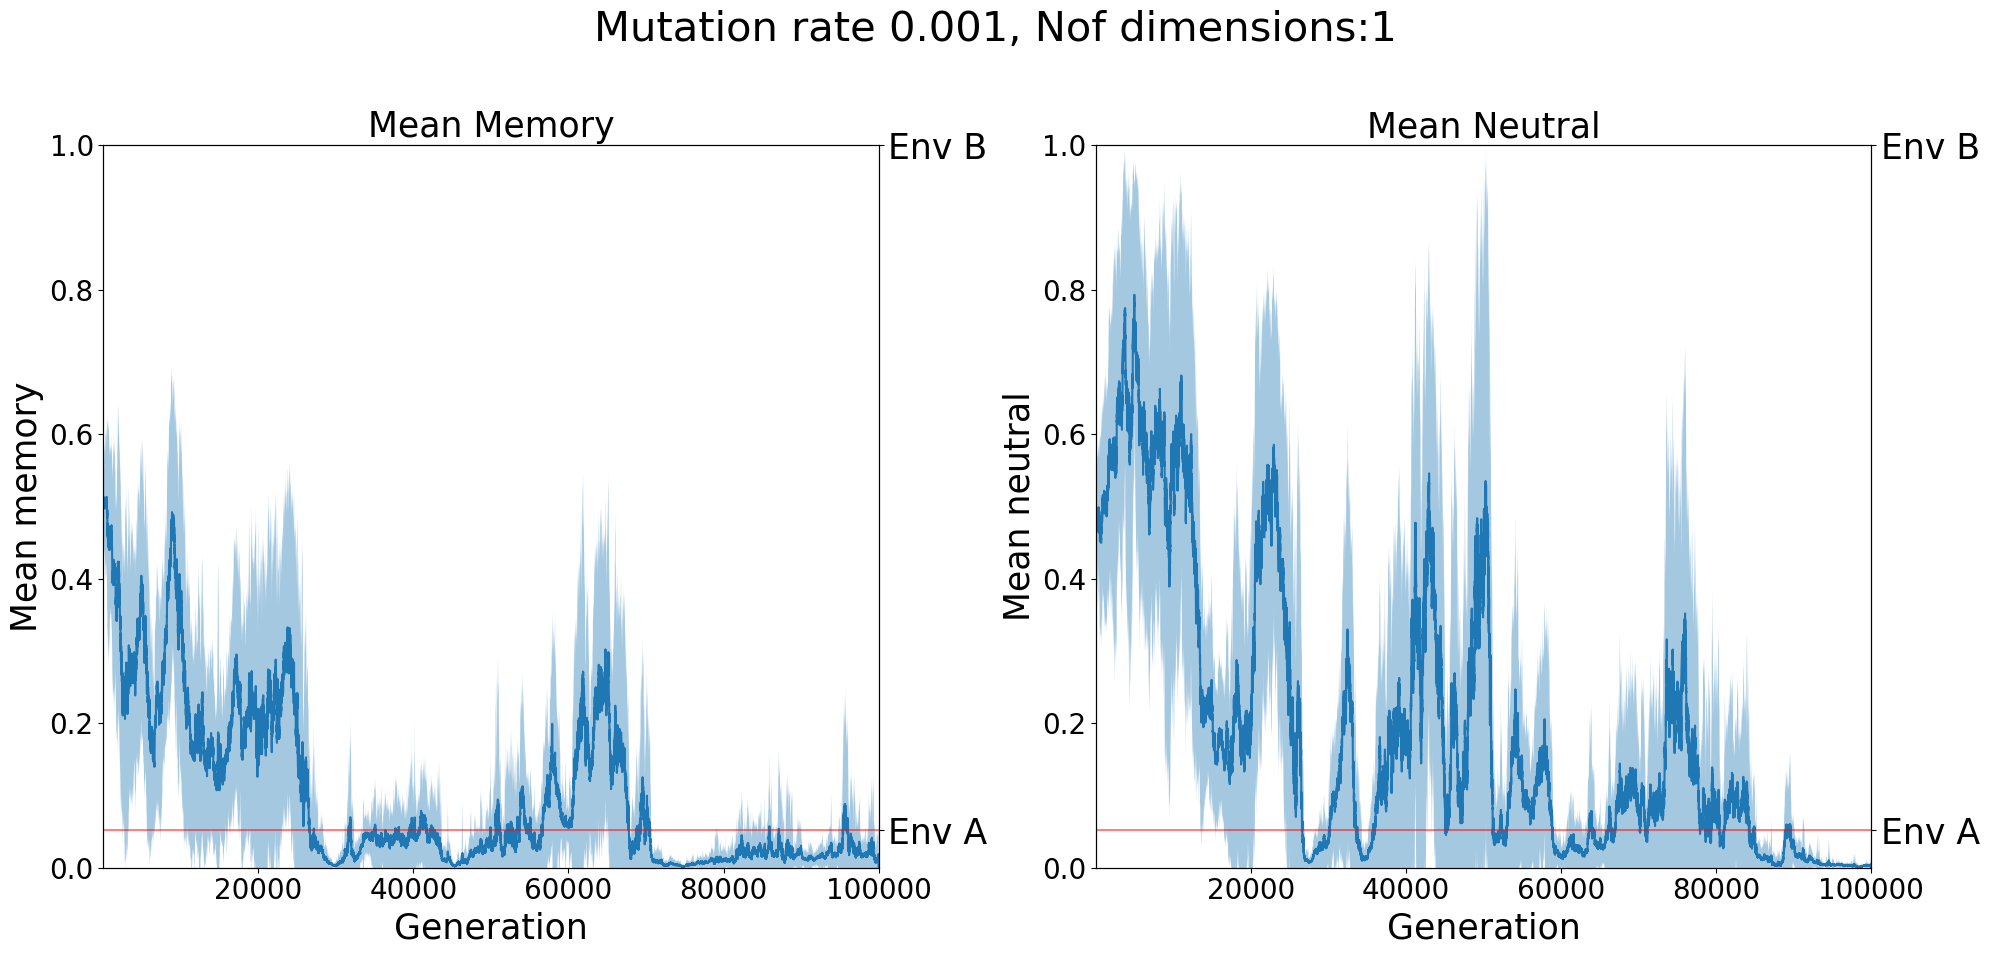

In [33]:
# Extract variables

maxgen = const['meanmemory_p'].shape[0]
gens = np.arange(1, maxgen +1 )   #Proper x-axis
meanmemory_p=const['meanmemory_p']
stdmemory_p=const['std_memory_p']
meanneutral_p= const['meanneutral_p']
stdneutral_p=const['std_neutral_p']
rho = clean_data_env[0]
m = clean_data_env[1]

# Create figure once (outside loop)
fig, ax = plt.subplots(1, 2, figsize=(20, 10), sharex=True)
ax2 = ax[0].twinx()
# Add labels, limits, and legends once
text_size = 25
axis_size= 20

# Left plot: mean memory
ax[0].plot(gens, meanmemory_p)
ax[0].fill_between(gens, meanmemory_p - stdmemory_p, 
                            meanmemory_p + stdmemory_p, alpha=0.4 )
ax2.plot(gens, env_states, color='red',  alpha = 0.5)
ax2.set_yticks([0, 1], ["Env A","Env B"], fontsize =text_size)
ax2 = ax[1].twinx()

# Right plot: mean neutral
ax[1].plot(meanneutral_p)
ax[1].fill_between(gens, meanneutral_p - stdneutral_p, 
                            meanneutral_p + stdneutral_p, alpha=0.4 )
ax2.plot(gens, env_states, color='red', alpha = 0.5)
ax2.set_yticks([0, 1], ["Env A","Env B"], fontsize =text_size)


    
ax[0].set_title("Mean Memory", fontsize =text_size)
ax[0].set_ylabel("Mean memory", fontsize =text_size)
ax[0].set_xlabel("Generation", fontsize =text_size)
ax[0].set_xlim(1, maxgen)
ax[0].set_ylim(0, 1)

ax[1].set_title("Mean Neutral", fontsize =text_size)
ax[1].set_ylabel("Mean neutral", fontsize =text_size)
        
ax[1].set_xlabel("Generation", fontsize =text_size)
ax[1].set_xlim(1, maxgen)
ax[1].set_ylim(0, 1)
ax[0].tick_params(axis='both', labelsize=axis_size)
ax[1].tick_params(axis='both', labelsize=axis_size)

#fig.suptitle(f"Mutation rate 0.001, Nof dimensions:{nof_dimensions}, rho:{nof_dimensions}, m: {m} ", fontsize=30)
fig.suptitle(f"Mutation rate 0.001, Nof dimensions:{nof_dimensions}", fontsize=30)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()